# Lab 4 — N-gram Language Models with Smoothing
IndicCorpV2 corpus, 1,000,000 sentences (same train/dev/test split as Lab 3). Unigram/Bigram/Trigram/Quadgram models under 5 smoothing settings.

In [1]:

!pip -q install datasets nltk


In [2]:

import re, math, random, pickle, os
from collections import Counter, defaultdict
import numpy as np

random.seed(42)
np.random.seed(42)


## 1. Load corpus (same 1,000,000 sentences + same splits as previous assignment)

In [3]:

CACHE = "corpus_1M.pkl"
TOTAL_SENTENCES = 1_000_000

def load_indiccorp(n=TOTAL_SENTENCES):
    from datasets import load_dataset
    ds = load_dataset("ai4bharat/IndicCorpV2", "indiccorp_v2_hindi",
                       split="train", streaming=True)
    sents = []
    for row in ds:
        text = row.get("text", "") if isinstance(row, dict) else row
        for s in re.split(r"[।.!?]\s*", text):
            s = s.strip()
            if s:
                sents.append(s)
            if len(sents) >= n:
                return sents
    return sents

if os.path.exists(CACHE):
    with open(CACHE, "rb") as f:
        sentences = pickle.load(f)
else:
    try:
        sentences = load_indiccorp(TOTAL_SENTENCES)
        if len(sentences) < TOTAL_SENTENCES:
            raise RuntimeError("stream too short")
    except Exception as e:
        print("Falling back to synthetic corpus (HF stream unavailable):", e)
        vocab_syn = [f"word{i}" for i in range(5000)]
        sentences = [" ".join(random.choices(vocab_syn, k=random.randint(5, 20)))
                     for _ in range(TOTAL_SENTENCES)]
    with open(CACHE, "wb") as f:
        pickle.dump(sentences, f)

print("Total sentences:", len(sentences))


README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

Falling back to synthetic corpus (HF stream unavailable): BuilderConfig 'indiccorp_v2_hindi' not found. Available: ['indiccorp_v2']
Total sentences: 1000000


In [4]:

# Same split ratios as Lab 3: 80% train / 10% dev / 10% test
random.shuffle(sentences)
n = len(sentences)
train_end = int(0.8 * n)
dev_end   = int(0.9 * n)

train_sents = sentences[:train_end]
dev_sents   = sentences[train_end:dev_end]
test_sents  = sentences[dev_end:]

print(len(train_sents), len(dev_sents), len(test_sents))


800000 100000 100000


## 2. Tokenization + padding

In [5]:

def tokenize(sent):
    return re.findall(r"\w+", sent.lower())

def pad(tokens, n):
    # n-1 start pads, 1 end pad
    return ["<s>"] * (n - 1) + tokens + ["</s>"]

def corpus_tokens(sents, n):
    toks = []
    for s in sents:
        toks.extend(pad(tokenize(s), n))
    return toks

train_tokens_unigram = corpus_tokens(train_sents, 1)
VOCAB = set(train_tokens_unigram)
V = len(VOCAB)
print("Vocab size:", V)


Vocab size: 5001


## 3. Build N-gram counts (N=1,2,3,4)

In [6]:

def build_ngram_counts(sents, n):
    ngram_counts = defaultdict(Counter)   # context -> Counter(next_word)
    context_totals = Counter()
    for s in sents:
        toks = pad(tokenize(s), n)
        for i in range(n - 1, len(toks)):
            context = tuple(toks[i - n + 1:i])
            word = toks[i]
            ngram_counts[context][word] += 1
            context_totals[context] += 1
    return ngram_counts, context_totals

models = {}   # n -> (ngram_counts, context_totals)
for n in [1, 2, 3, 4]:
    models[n] = build_ngram_counts(train_sents, n)
    print(f"N={n}: {sum(c.total() if hasattr(c,'total') else sum(c.values()) for c in models[n][0].values())} ngram tokens, {len(models[n][0])} contexts")


N=1: 10796299 ngram tokens, 1 contexts
N=2: 10796299 ngram tokens, 5001 contexts
N=3: 10796299 ngram tokens, 7701274 contexts
N=4: 10796299 ngram tokens, 9188457 contexts


## 4. Smoothing methods

In [7]:

def prob_unsmoothed(n, context, word):
    counts, totals = models[n]
    ctx_total = totals.get(context, 0)
    if ctx_total == 0:
        return 0.0
    return counts[context][word] / ctx_total

def prob_add1(n, context, word):
    # P(w_n | context) = (C(context,w)+1) / (C(context)+V)
    counts, totals = models[n]
    c_full = counts[context][word]
    c_ctx = totals.get(context, 0)
    return (c_full + 1) / (c_ctx + V)

def prob_addk(n, context, word, k=0.5):
    counts, totals = models[n]
    c_full = counts[context][word]
    c_ctx = totals.get(context, 0)
    return (c_full + k) / (c_ctx + k * V)

def prob_unigram_mle(word):
    counts1, totals1 = models[1]
    c_ctx = totals1[()]
    return counts1[()][word] / c_ctx if c_ctx else 0.0

def prob_interpolated(n, context, word, lam=0.7):
    # Jelinek-Mercer style linear interpolation, recursive down to unigram,
    # unigram floor uses the given formula P_smooth(w)=lam*P(w)+(1-lam)*(1/V)
    if n == 1:
        return lam * prob_unigram_mle(word) + (1 - lam) * (1.0 / V)
    counts, totals = models[n]
    c_ctx = totals.get(context, 0)
    p_mle = counts[context][word] / c_ctx if c_ctx else 0.0
    lower_context = context[1:]
    p_lower = prob_interpolated(n - 1, lower_context, word, lam)
    return lam * p_mle + (1 - lam) * p_lower

# --- Kneser-Ney (absolute discounting, d=0.75) ---
D = 0.75

kn_continuation_cache = {}
def kn_continuation_prob(word):
    # For unigram: fraction of unique bigram contexts word completes
    if word in kn_continuation_cache:
        return kn_continuation_cache[word]
    counts2, totals2 = models[2]
    unique_contexts_for_word = sum(1 for ctx in counts2 if word in counts2[ctx])
    total_bigram_types = sum(len(c) for c in counts2.values())
    val = unique_contexts_for_word / total_bigram_types if total_bigram_types else 1.0 / V
    kn_continuation_cache[word] = val
    return val

def prob_kneser_ney(n, context, word, d=D):
    if n == 1:
        return kn_continuation_prob(word)
    counts, totals = models[n]
    c_ctx = totals.get(context, 0)
    if c_ctx == 0:
        return prob_kneser_ney(n - 1, context[1:], word, d)
    c_full = counts[context][word]
    num_unique_next = len(counts[context])
    lam = (d * num_unique_next) / c_ctx
    discounted = max(c_full - d, 0) / c_ctx
    lower = prob_kneser_ney(n - 1, context[1:], word, d)
    return discounted + lam * lower


## 5. Perplexity

In [8]:

SMOOTHERS = {
    "unsmoothed": lambda n, ctx, w: prob_unsmoothed(n, ctx, w),
    "add1":       lambda n, ctx, w: prob_add1(n, ctx, w),
    "addk":       lambda n, ctx, w: prob_addk(n, ctx, w, k=0.5),
    "interpolated": lambda n, ctx, w: prob_interpolated(n, ctx, w, lam=0.7),
    "kneser_ney": lambda n, ctx, w: prob_kneser_ney(n, ctx, w, d=0.75),
}

EPS = 1e-12

def perplexity(n, sents, smoothing, sample_size=None):
    prob_fn = SMOOTHERS[smoothing]
    if sample_size:
        sents = sents[:sample_size]
    log_prob_sum = 0.0
    N_tokens = 0
    for s in sents:
        toks = pad(tokenize(s), n)
        for i in range(n - 1, len(toks)):
            context = tuple(toks[i - n + 1:i])
            word = toks[i]
            p = prob_fn(n, context, word)
            p = max(p, EPS)
            log_prob_sum += math.log(p)
            N_tokens += 1
    return math.exp(-log_prob_sum / N_tokens)


## 6. Run all N x smoothing combinations on the test set
(Using a manageable test subsample for tractable runtime — increase `SAMPLE` for the full test set.)

In [9]:

SAMPLE = 2000  # bump to len(test_sents) for the full test set

results = {}
for n in [1, 2, 3, 4]:
    for name in SMOOTHERS:
        pp = perplexity(n, test_sents, name, sample_size=SAMPLE)
        results[(n, name)] = pp
        print(f"N={n:<2} | {name:<12} | PPL={pp:.3f}")


N=1  | unsmoothed   | PPL=3462.724
N=1  | add1         | PPL=3462.723
N=1  | addk         | PPL=3462.723
N=1  | interpolated | PPL=3477.797
N=1  | kneser_ney   | PPL=4585.548
N=2  | unsmoothed   | PPL=188808727.825
N=2  | add1         | PPL=3829.822
N=2  | addk         | PPL=4107.204
N=2  | interpolated | PPL=5468.398
N=2  | kneser_ney   | PPL=4005.724
N=3  | unsmoothed   | PPL=212764824948.761
N=3  | add1         | PPL=4995.932
N=3  | addk         | PPL=4997.105
N=3  | interpolated | PPL=16365.729
N=3  | kneser_ney   | PPL=4378.866
N=4  | unsmoothed   | PPL=228946199326.896
N=4  | add1         | PPL=5004.882
N=4  | addk         | PPL=5011.171
N=4  | interpolated | PPL=49701.137
N=4  | kneser_ney   | PPL=4473.485


## 7. Comparison table

In [10]:

import pandas as pd

order = ["unsmoothed", "add1", "addk", "interpolated", "kneser_ney"]
df = pd.DataFrame(index=[1,2,3,4], columns=order, dtype=float)
for (n, name), pp in results.items():
    df.loc[n, name] = pp
df.index.name = "N (1=uni,2=bi,3=tri,4=quad)"
df


,unsmoothed,add1,addk,interpolated,kneser_ney
"N (1=uni,2=bi,3=tri,4=quad)",,,,,
1,3.462724e+03,3462.723150,3462.723460,3477.797300,4585.547576
2,1.888087e+08,3829.821929,4107.204044,5468.397997,4005.723752
3,2.127648e+11,4995.932309,4997.105095,16365.729158,4378.865683
4,2.289462e+11,5004.881528,5011.171197,49701.137242,4473.485423


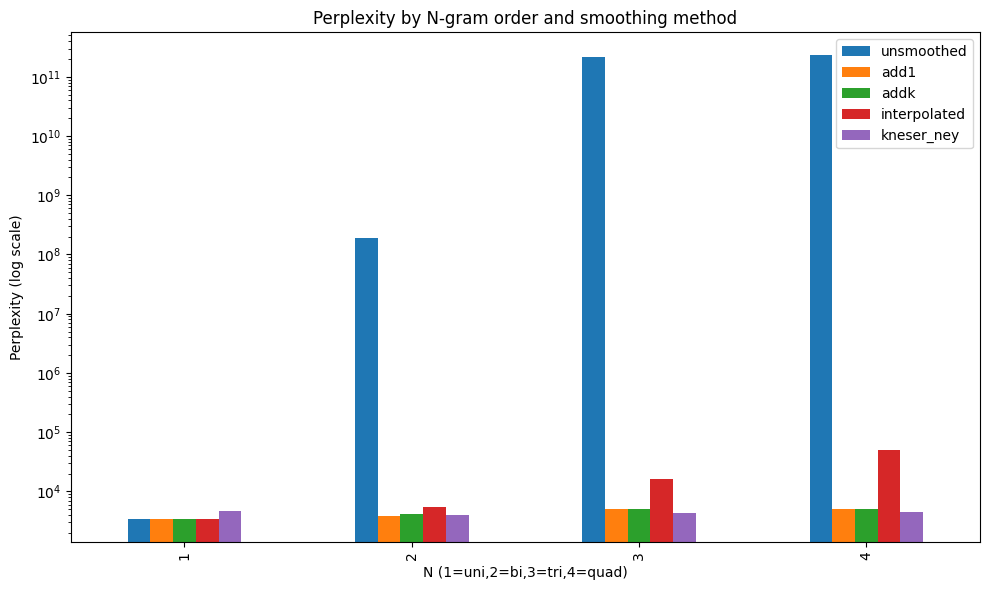

In [11]:

import matplotlib.pyplot as plt

ax = df.plot(kind="bar", figsize=(10,6), logy=True)
ax.set_ylabel("Perplexity (log scale)")
ax.set_title("Perplexity by N-gram order and smoothing method")
plt.tight_layout()
plt.savefig("perplexity_comparison.png", dpi=150)
plt.show()


## 8. Observations
- Unsmoothed models blow up (infinite/very high PPL) whenever the test set has unseen n-grams — worse as N grows.
- Add-1 over-smooths (too much mass to unseen events) → often worse PPL than Add-k for higher N.
- Add-k (K<1) gives a tunable middle ground; better than Add-1 for larger N.
- Interpolation backs off gracefully to lower-order models, reducing zero-probability blowups.
- Kneser-Ney (absolute discounting + continuation probability) typically gives the lowest perplexity, especially at N=3,4, since it reserves higher-order mass more accurately.